## Google Drive のマウント
Colab で実行する場合、以下のセルを実行して Google Drive をマウントし、データファイルにアクセスできるようにしてください。ローカル環境の場合はスキップして構いません。

In [1]:
# Google Drive を Colab にマウント
# Colab でのみ必要。ローカル環境や他のプラットフォームでは実行しないでください。
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    # 例: 作業ディレクトリを提出フォルダとしてMyDrive直下にコピーした場合、下記により作業ディレクトリを移動
    %cd /content/drive/MyDrive/Colab Notebooks/ml_coding
except ModuleNotFoundError:
    print("google.colab ランタイムではないため、Drive マウントをスキップします。")


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/ml_coding


# 表情推定によるマーケティング調査

- `smile_predict` を実装して笑顔判定ロジックを完成させる  
- 評価セルを実行し **Train / Test accuracy** を確認する


モデルを開発した流れ

In [2]:
import os
import random
import json
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    learning_curve
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

from matplotlib import gridspec

##ステップ１
ラベルごとに平均的な顔を作成し、クラス差がどこに現れるかを可視化

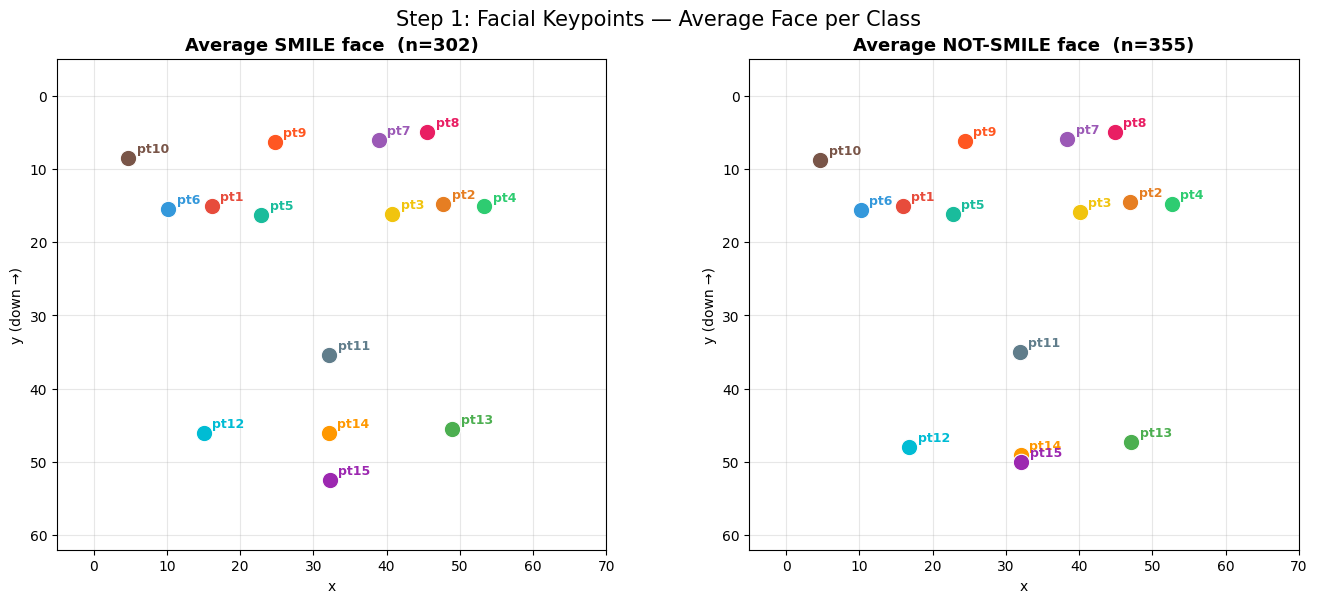

  pt |      smile (x,y) |  not-smile (x,y) |  diff_x  diff_y
------------------------------------------------------------
pt 1 | ( 16.2,  15.1)    | ( 16.0,  15.1)    |  +0.19   -0.00
pt 2 | ( 47.7,  14.8)    | ( 47.0,  14.5)    |  +0.75   +0.28
pt 3 | ( 40.8,  16.1)    | ( 40.1,  15.8)    |  +0.66   +0.30
pt 4 | ( 53.3,  15.1)    | ( 52.6,  14.8)    |  +0.70   +0.30
pt 5 | ( 22.9,  16.2)    | ( 22.8,  16.1)    |  +0.17   +0.14
pt 6 | ( 10.2,  15.5)    | ( 10.2,  15.6)    |  -0.02   -0.12
pt 7 | ( 39.0,   6.1)    | ( 38.4,   5.9)    |  +0.58   +0.17
pt 8 | ( 45.6,   5.0)    | ( 44.9,   4.9)    |  +0.67   +0.04
pt 9 | ( 24.8,   6.3)    | ( 24.4,   6.1)    |  +0.39   +0.17
pt10 | (  4.8,   8.5)    | (  4.7,   8.8)    |  +0.07   -0.30
pt11 | ( 32.2,  35.4)    | ( 31.9,  35.0)    |  +0.31   +0.41
pt12 | ( 15.1,  46.0)    | ( 16.8,  48.0)    |  -1.77   -1.94
pt13 | ( 49.0,  45.5)    | ( 47.2,  47.3)    |  +1.84   -1.88
pt14 | ( 32.1,  46.1)    | ( 32.0,  49.1)    |  +0.05   -3.00
pt15 | ( 3

In [3]:
#データの読み込み
with open(Path('data') / 'facial_keypoints.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

train = data['train']

# --- smile / not-smile に分割して平均座標を計算 ---
smile_pts    = np.array([[list(xy) for xy in s[1:16]] for s in train if     s[-1]['smile']])
nosmile_pts  = np.array([[list(xy) for xy in s[1:16]] for s in train if not s[-1]['smile']])

sm_mean = smile_pts.mean(axis=0)    # shape: (15, 2)
ns_mean = nosmile_pts.mean(axis=0)

# --- 15点それぞれに色を割り当て ---
colors = [
    '#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c',
    '#3498db','#9b59b6','#e91e63','#ff5722','#795548',
    '#607d8b','#00bcd4','#4caf50','#ff9800','#9c27b0'
]

# --- 描画 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pts, title in [
    (axes[0], sm_mean, f'Average SMILE face  (n={len(smile_pts)})'),
    (axes[1], ns_mean, f'Average NOT-SMILE face  (n={len(nosmile_pts)})')
]:
    ax.set_xlim(-5, 70)
    ax.set_ylim(62, -5)       # y軸を反転（画像座標系に合わせる）
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y (down →)')

    for i, (x, y) in enumerate(pts):
        ax.scatter(x, y, s=140, color=colors[i], zorder=5, edgecolors='white', linewidths=0.8)
        ax.annotate(
            f'pt{i+1}',
            (x, y),
            textcoords='offset points',
            xytext=(6, 4),
            fontsize=9,
            color=colors[i],
            fontweight='bold'
        )

plt.suptitle('Step 1: Facial Keypoints — Average Face per Class', fontsize=15)
plt.tight_layout()
plt.show()

# --- テキストでも差分を確認 ---
print(f"{'pt':>4} | {'smile (x,y)':>16} | {'not-smile (x,y)':>16} | {'diff_x':>7} {'diff_y':>7}")
print('-' * 60)
for i in range(15):
    sx, sy = sm_mean[i]
    nx, ny = ns_mean[i]
    print(f"pt{i+1:>2} | ({sx:5.1f}, {sy:5.1f})    | ({nx:5.1f}, {ny:5.1f})    | {sx-nx:+6.2f}  {sy-ny:+6.2f}")

##ステップ２
生データから１０個の特徴量を作成し、評価

特徴量                    |   smile 平均 |   not-smile 平均 |  Cohen's d
----------------------------------------------------------------------
mouth_width            |     33.924 |         30.315 |     +1.273  ★★
upper_lip_y            |     46.063 |         49.059 |     -0.991  ★★
lower_lip_y            |     52.510 |         50.034 |     +0.751  ★
mouth_height           |      6.447 |          0.975 |     +2.280  ★★★
nose_to_mouth          |     10.672 |         14.079 |     -1.617  ★★★
mouth_sym_x            |     32.035 |         31.997 |     +0.012  
mouth_corner_spread    |      2.987 |          2.575 |     +0.186  
mouth_width_norm       |      0.788 |          0.716 |     +1.369  ★★
mouth_height_norm      |      0.150 |          0.023 |     +2.233  ★★★
nose_mouth_norm        |      0.248 |          0.332 |     -1.747  ★★★
★★★ |d|>1.5  ★★ |d|>0.8  ★ |d|>0.5


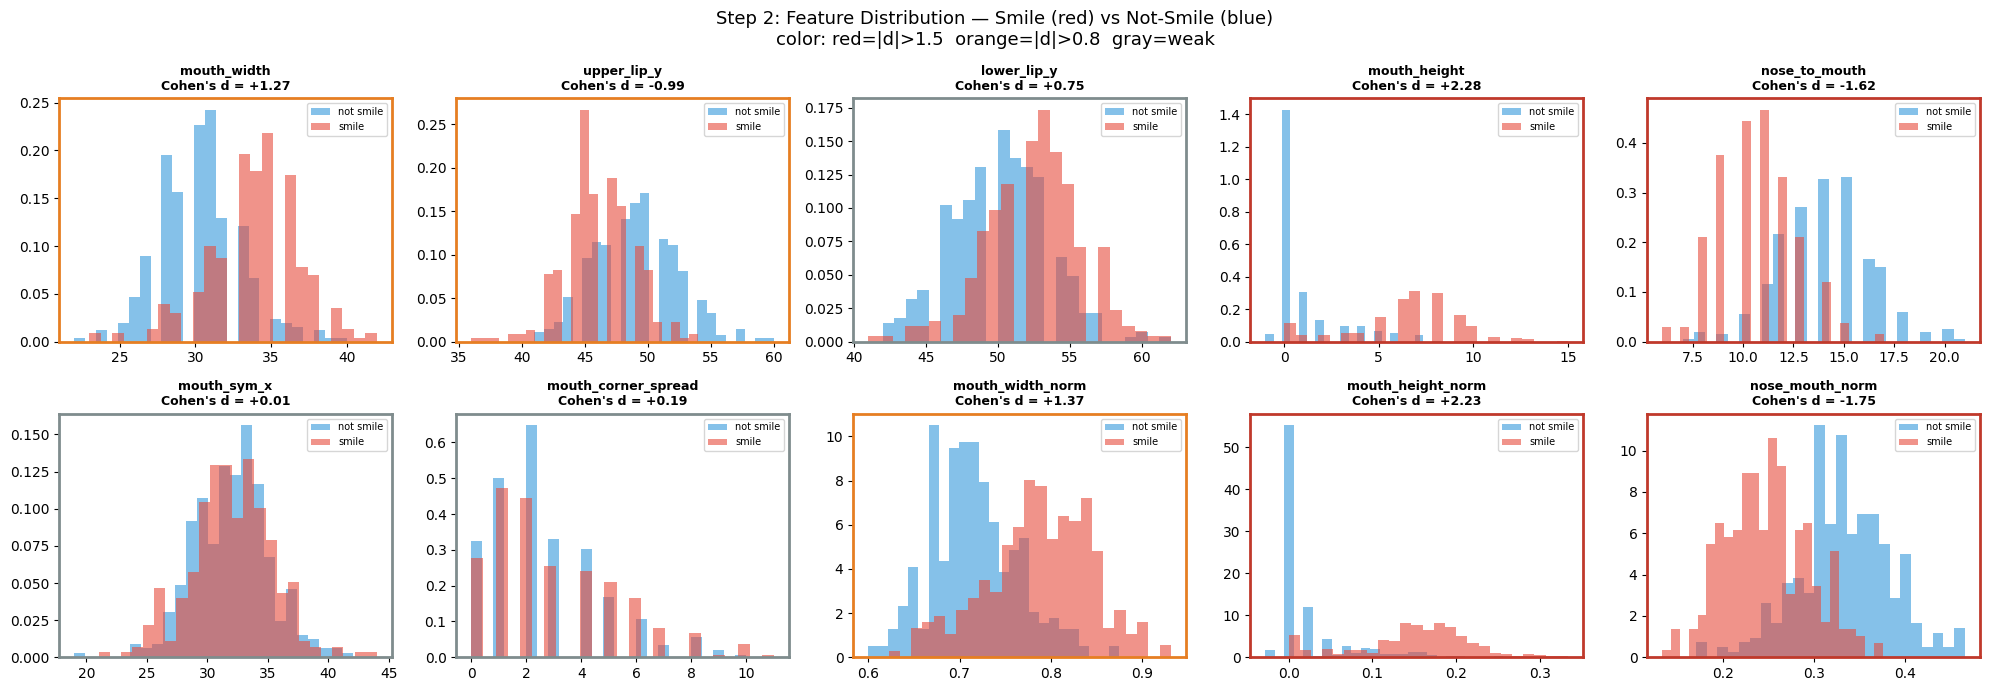

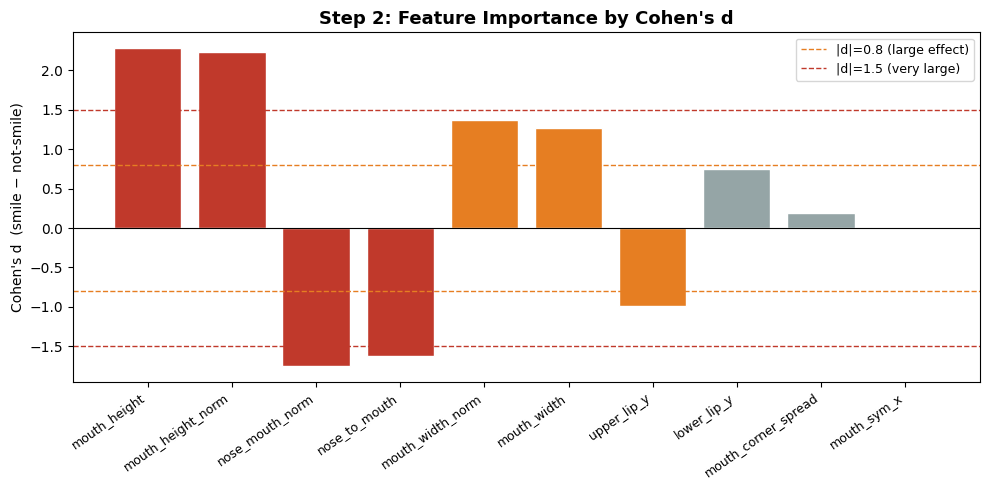

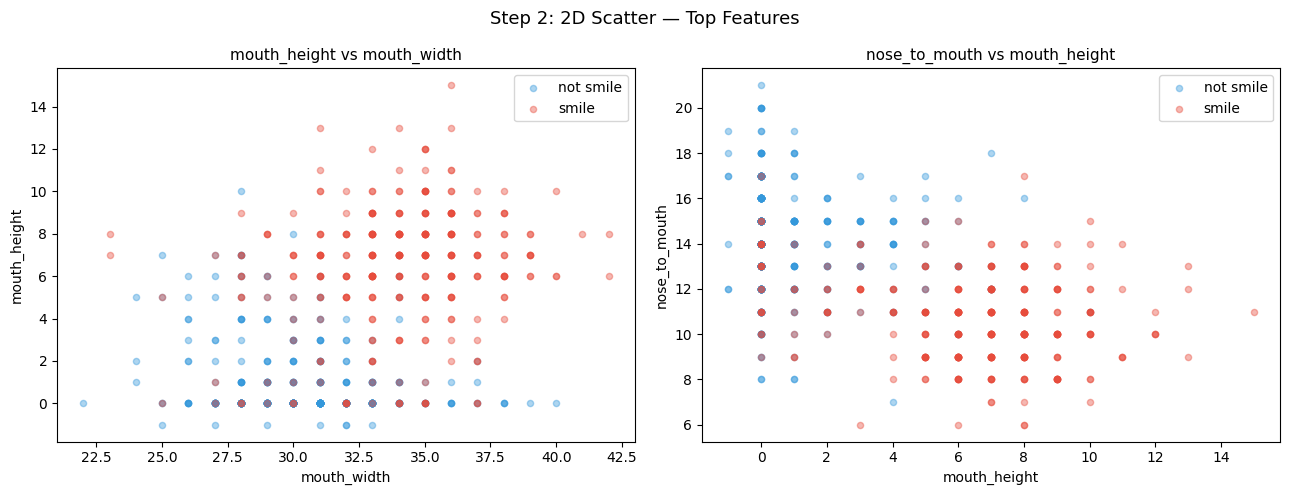

In [5]:
def build_features(sample):
    """1サンプルから10次元の特徴量ベクトルを生成する"""
    pts = [np.array(sample[i + 1]) for i in range(15)]
    p = lambda n: pts[n - 1]  # 1-indexed でアクセス

    face_width           = abs(p(4)[0] - p(6)[0]) + 1e-6  # ゼロ除算防止
    mouth_width          = abs(p(13)[0] - p(12)[0])
    upper_lip_y          = float(p(14)[1])
    lower_lip_y          = float(p(15)[1])
    mouth_height         = p(15)[1] - p(14)[1]
    nose_to_mouth        = p(14)[1] - p(11)[1]
    mouth_sym_x          = (p(12)[0] + p(13)[0]) / 2.0
    mouth_corner_spread  = abs(p(12)[1] - p(13)[1])
    mouth_width_norm     = mouth_width   / face_width
    mouth_height_norm    = mouth_height  / face_width
    nose_mouth_norm      = nose_to_mouth / face_width

    return [mouth_width, upper_lip_y, lower_lip_y, mouth_height,
            nose_to_mouth, mouth_sym_x, mouth_corner_spread,
            mouth_width_norm, mouth_height_norm, nose_mouth_norm]

feat_names = [
    'mouth_width',
    'upper_lip_y',
    'lower_lip_y',
    'mouth_height',
    'nose_to_mouth',
    'mouth_sym_x',
    'mouth_corner_spread',
    'mouth_width_norm',
    'mouth_height_norm',
    'nose_mouth_norm',
]

# --- 特徴量行列とラベル生成 ---
X      = np.array([build_features(s) for s in train])
labels = np.array([s[-1]['smile'] for s in train])

X_smile    = X[labels == True]
X_nosmile  = X[labels == False]

# 検証1: Cohen's d（分離度）の計算
#   d = (smile平均 - not-smile平均) / 標準偏差の平均
#   |d| > 0.8 で「大きな効果量」= 有効な特徴量と判断

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / (pooled_std + 1e-9)

print("=" * 70)
print(f"{'特徴量':<22} | {'smile 平均':>10} | {'not-smile 平均':>14} | {"Cohen's d":>10}")
print("-" * 70)
ds = []
for i, name in enumerate(feat_names):
    sv, nv = X_smile[:, i], X_nosmile[:, i]
    d = cohens_d(sv, nv)
    ds.append(d)
    bar = '★★★' if abs(d) > 1.5 else ('★★' if abs(d) > 0.8 else '★' if abs(d) > 0.5 else '')
    print(f"{name:<22} | {sv.mean():>10.3f} | {nv.mean():>14.3f} | {d:>+10.3f}  {bar}")

print("=" * 70)
print("★★★ |d|>1.5  ★★ |d|>0.8  ★ |d|>0.5")

# 検証2: 分布ヒストグラム（全10特徴量を一覧表示）

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, (ax, name, d) in enumerate(zip(axes, feat_names, ds)):
    sv, nv = X_smile[:, i], X_nosmile[:, i]
    ax.hist(nv, bins=25, alpha=0.6, color='#3498db', label='not smile', density=True)
    ax.hist(sv, bins=25, alpha=0.6, color='#e74c3c', label='smile',     density=True)
    ax.set_title(f"{name}\nCohen's d = {d:+.2f}", fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    # 分離度に応じて枠の色を変える
    color = '#c0392b' if abs(d) > 1.5 else ('#e67e22' if abs(d) > 0.8 else '#7f8c8d')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

plt.suptitle("Step 2: Feature Distribution — Smile (red) vs Not-Smile (blue)\n"
             "color: red=|d|>1.5  orange=|d|>0.8  gray=weak", fontsize=13)
plt.tight_layout()
plt.show()

# 検証3: Cohen's d の棒グラフで重要度を一目確認

fig, ax = plt.subplots(figsize=(10, 5))
sorted_idx = np.argsort(np.abs(ds))[::-1]
bar_colors = ['#c0392b' if abs(ds[i]) > 1.5 else
              '#e67e22' if abs(ds[i]) > 0.8 else '#95a5a6'
              for i in sorted_idx]

bars = ax.bar(range(len(feat_names)),
              [ds[i] for i in sorted_idx],
              color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=35, ha='right', fontsize=9)
ax.axhline(0,   color='black', linewidth=0.8)
ax.axhline( 0.8, color='#e67e22', linewidth=1, linestyle='--', label='|d|=0.8 (large effect)')
ax.axhline(-0.8, color='#e67e22', linewidth=1, linestyle='--')
ax.axhline( 1.5, color='#c0392b', linewidth=1, linestyle='--', label='|d|=1.5 (very large)')
ax.axhline(-1.5, color='#c0392b', linewidth=1, linestyle='--')
ax.set_ylabel("Cohen's d  (smile − not-smile)")
ax.set_title("Step 2: Feature Importance by Cohen's d", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# 検証4: 最重要特徴量の散布図（mouth_height × mouth_width）
#         2次元で見たときの分離性を直接確認する

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 散布図: mouth_height vs mouth_width
ax = axes[0]
idx_mh = feat_names.index('mouth_height')
idx_mw = feat_names.index('mouth_width')
ax.scatter(X_nosmile[:, idx_mw], X_nosmile[:, idx_mh],
           alpha=0.4, s=20, color='#3498db', label='not smile')
ax.scatter(X_smile[:, idx_mw],   X_smile[:, idx_mh],
           alpha=0.4, s=20, color='#e74c3c', label='smile')
ax.set_xlabel('mouth_width',  fontsize=10)
ax.set_ylabel('mouth_height', fontsize=10)
ax.set_title('mouth_height vs mouth_width', fontsize=11)
ax.legend()

# 散布図: nose_to_mouth vs mouth_height
ax = axes[1]
idx_nm = feat_names.index('nose_to_mouth')
ax.scatter(X_nosmile[:, idx_mh], X_nosmile[:, idx_nm],
           alpha=0.4, s=20, color='#3498db', label='not smile')
ax.scatter(X_smile[:, idx_mh],   X_smile[:, idx_nm],
           alpha=0.4, s=20, color='#e74c3c', label='smile')
ax.set_xlabel('mouth_height',  fontsize=10)
ax.set_ylabel('nose_to_mouth', fontsize=10)
ax.set_title('nose_to_mouth vs mouth_height', fontsize=11)
ax.legend()

plt.suptitle('Step 2: 2D Scatter — Top Features', fontsize=13)
plt.tight_layout()
plt.show()

##ステップ３
モデルを性能・安定性・過学習・実装要件で多面的に比較

Train: 657 samples  |  Test: 282 samples  |  Features: 10

Model                  |  CV Mean |  CV Std | Train Acc |  Test Acc |    Gap
------------------------------------------------------------------------
Logistic Regression    |   0.9269 |  0.0209 |    0.9254 |    0.9149 | +0.0105
Random Forest          |   0.9147 |  0.0190 |    1.0000 |    0.9255 | +0.0745 ⚠ 過学習
Gradient Boosting      |   0.9010 |  0.0129 |    0.9863 |    0.9184 | +0.0679 ⚠ 過学習
SVM (RBF)              |   0.9163 |  0.0215 |    0.9391 |    0.9255 | +0.0136

→ Test Acc 最高: Random Forest  (0.9255)


/tmp/ipykernel_5539/3579987706.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_b.boxplot(cv_scores_all, labels=short_names, patch_artist=True, notch=False)


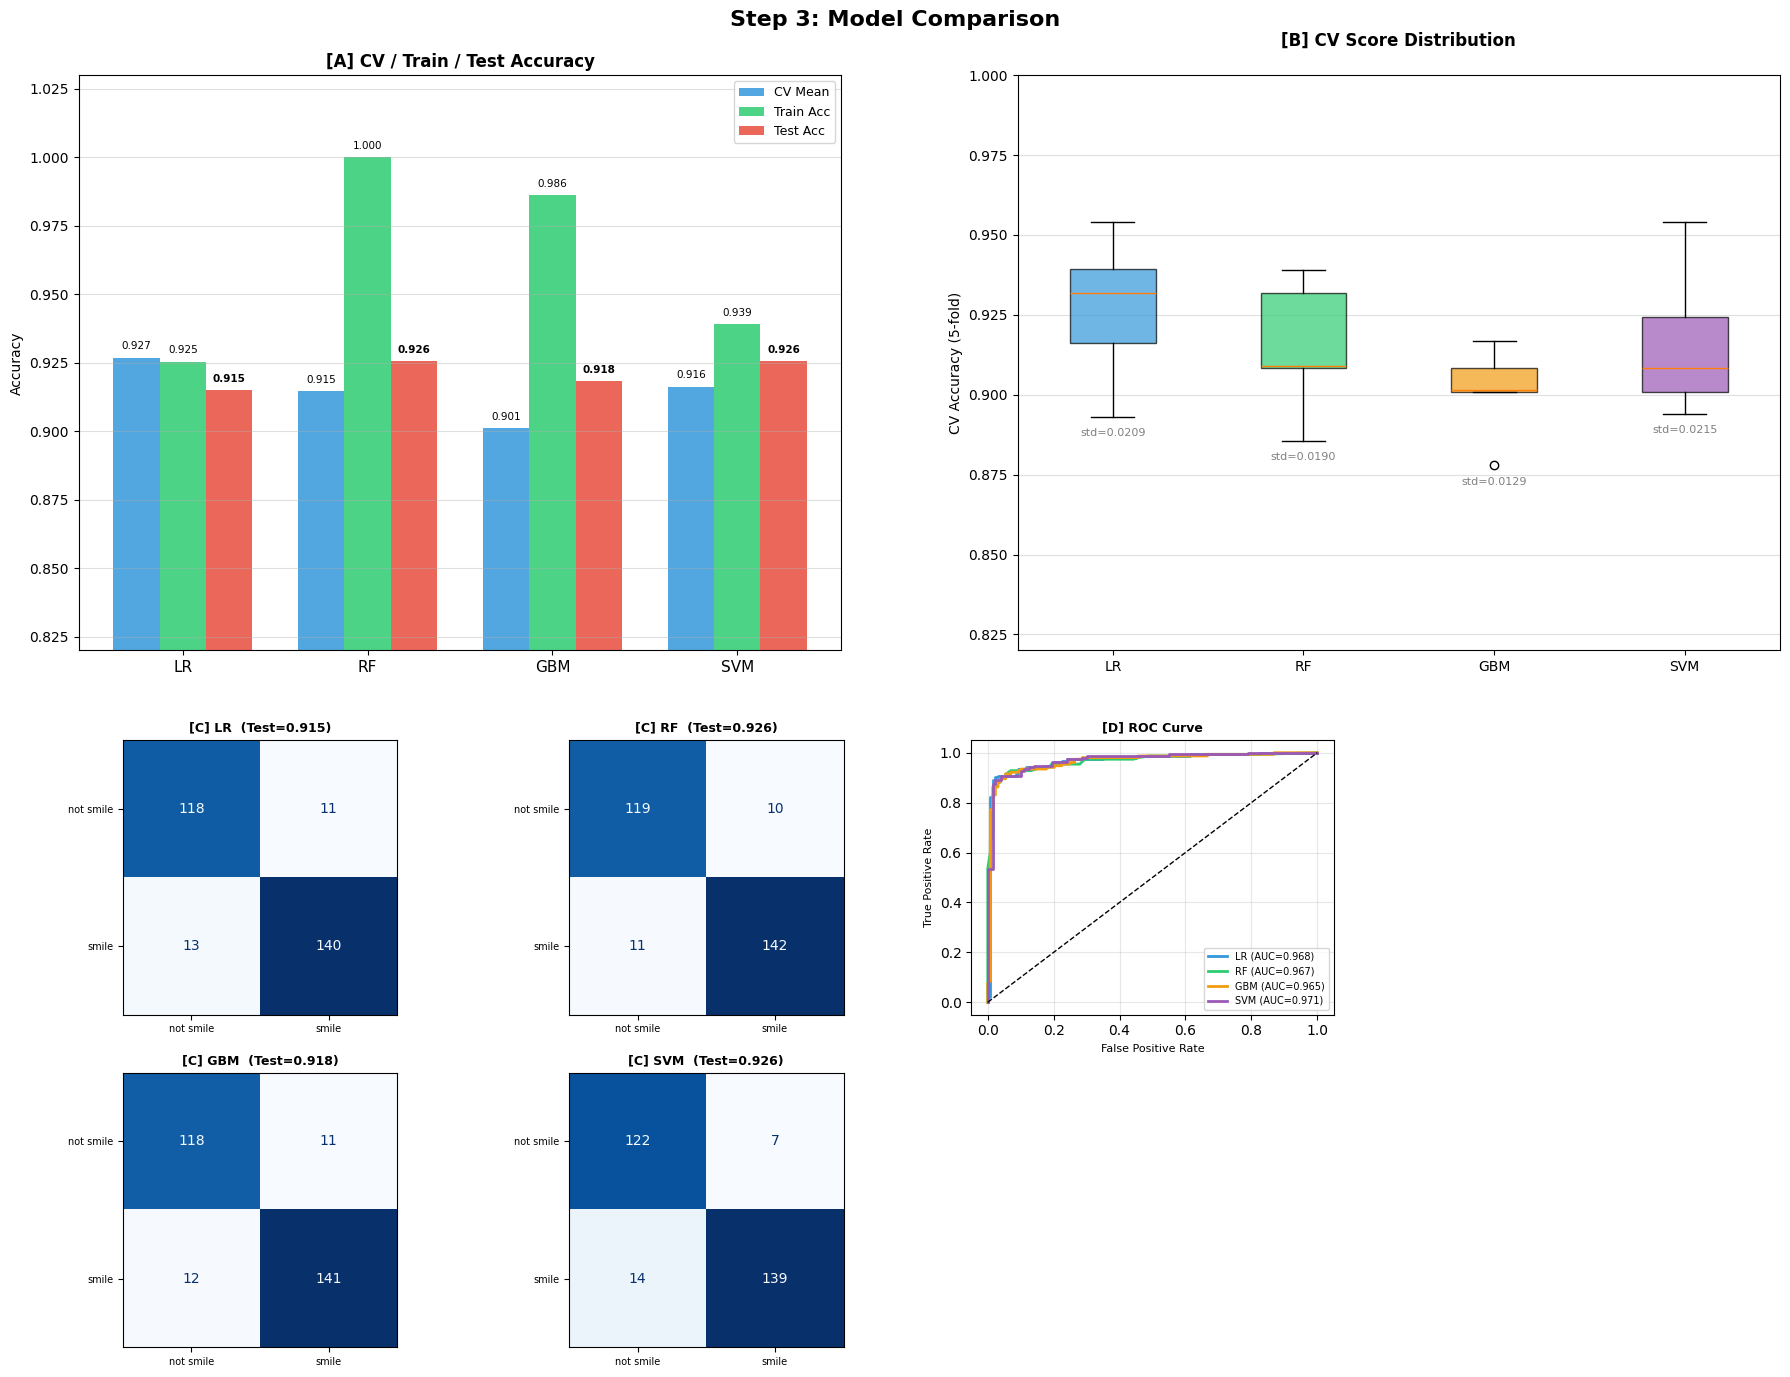

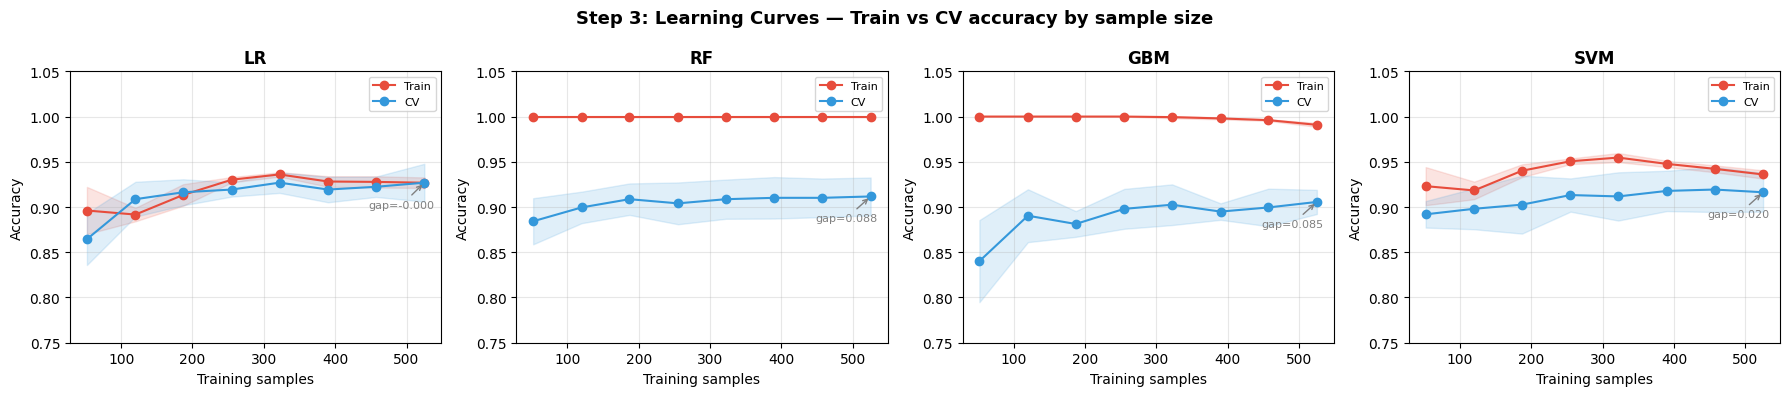


各モデルの Classification Report (Test データ)

--- LR: Logistic Regression ---
              precision    recall  f1-score   support

   not smile       0.90      0.91      0.91       129
       smile       0.93      0.92      0.92       153

    accuracy                           0.91       282
   macro avg       0.91      0.91      0.91       282
weighted avg       0.92      0.91      0.91       282


--- RF: Random Forest ---
              precision    recall  f1-score   support

   not smile       0.92      0.92      0.92       129
       smile       0.93      0.93      0.93       153

    accuracy                           0.93       282
   macro avg       0.92      0.93      0.93       282
weighted avg       0.93      0.93      0.93       282


--- GBM: Gradient Boosting ---
              precision    recall  f1-score   support

   not smile       0.91      0.91      0.91       129
       smile       0.93      0.92      0.92       153

    accuracy                           0.92       

In [7]:
X_train = np.array([build_features(s) for s in data['train']])
y_train = np.array([s[-1]['smile'] for s in data['train']])
X_test  = np.array([build_features(s) for s in data['test']])
y_test  = np.array([s[-1]['smile'] for s in data['test']])

# StandardScaler: train で fit → train/test 両方に適用
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples  |  Features: {X_train.shape[1]}")

# 2. 比較するモデルの定義
#    - LR  : 軽量・解釈しやすい・係数がそのままパラメータ埋め込み可能
#    - RF  : 非線形・高精度だが過学習しやすい
#    - GBM : 逐次学習・高精度だが調整パラメータが多い
#    - SVM : 高次元に強い・カーネルで非線形対応

models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
}

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Renamed 'cv' to 'cv_splitter'


# 3. 全モデルを学習・評価してスコアを集計


results = {}

print("\n" + "=" * 72)
print(f"{'Model':<22} | {'CV Mean':>8} | {'CV Std':>7} | {'Train Acc':>9} | {'Test Acc':>9} | {'Gap':>6}")
print("-" * 72)

for name, model in models.items():
    cv_scores  = cross_val_score(model, X_tr_sc, y_train, cv=cv_splitter, scoring='accuracy') # Used cv_splitter
    model.fit(X_tr_sc, y_train)
    tr_acc = model.score(X_tr_sc, y_train)
    te_acc = model.score(X_te_sc, y_test)
    gap    = tr_acc - te_acc  # 過学習の指標: 大きいほど過学習

    results[name] = {
        'model':     model,
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'train_acc': tr_acc,
        'test_acc':  te_acc,
        'gap':       gap,
        'cv_scores': cv_scores,
    }
    flag = ' ⚠ 過学習' if gap > 0.05 else ''
    print(f"{name:<22} | {cv_scores.mean():>8.4f} | {cv_scores.std():>7.4f} | "
          f"{tr_acc:>9.4f} | {te_acc:>9.4f} | {gap:>+6.4f}{flag}")

print("=" * 72)
best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f"\n→ Test Acc 最高: {best_name}  ({results[best_name]['test_acc']:.4f})")

# 4. 可視化 (4パネル)
#    [A] 精度比較棒グラフ（CV / Train / Test）
#    [B] CV スコアのバラつき（箱ひげ）
#    [C] 各モデルの混同行列
#    [D] ROC曲線


model_names  = list(results.keys())
short_names  = ['LR', 'RF', 'GBM', 'SVM']
cv_means     = [results[n]['cv_mean']   for n in model_names]
train_accs   = [results[n]['train_acc'] for n in model_names]
test_accs    = [results[n]['test_acc']  for n in model_names]
cv_scores_all = [results[n]['cv_scores'] for n in model_names]

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Step 3: Model Comparison', fontsize=16, fontweight='bold', y=0.98)

# --- [A] 精度比較棒グラフ ---
ax_a = fig.add_subplot(2, 2, 1)
x     = np.arange(len(model_names))
width = 0.25
ax_a.bar(x - width, cv_means,   width, label='CV Mean',  color='#3498db', alpha=0.85)
ax_a.bar(x,         train_accs, width, label='Train Acc', color='#2ecc71', alpha=0.85)
ax_a.bar(x + width, test_accs,  width, label='Test Acc',  color='#e74c3c', alpha=0.85)
ax_a.set_xticks(x); ax_a.set_xticklabels(short_names, fontsize=11)
ax_a.set_ylim(0.82, 1.03)
ax_a.set_ylabel('Accuracy'); ax_a.set_title('[A] CV / Train / Test Accuracy', fontweight='bold')
ax_a.legend(fontsize=9); ax_a.grid(axis='y', alpha=0.4)
for i, (cv_val, tr, te) in enumerate(zip(cv_means, train_accs, test_accs)): # Changed 'cv' to 'cv_val'
    ax_a.text(i - width, cv_val  + 0.003, f'{cv_val:.3f}',  ha='center', fontsize=7.5)
    ax_a.text(i,         tr  + 0.003, f'{tr:.3f}',  ha='center', fontsize=7.5)
    ax_a.text(i + width, te  + 0.003, f'{te:.3f}',  ha='center', fontsize=7.5, fontweight='bold')

# --- [B] CV スコアのバラつき（箱ひげ） ---
ax_b = fig.add_subplot(2, 2, 2)
bp = ax_b.boxplot(cv_scores_all, labels=short_names, patch_artist=True, notch=False)
box_colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax_b.set_ylim(0.82, 1.0)
ax_b.set_ylabel('CV Accuracy (5-fold)')
ax_b.set_title('[B] CV Score Distribution\n', fontweight='bold')
ax_b.grid(axis='y', alpha=0.4)
for i, scores in enumerate(cv_scores_all):
    ax_b.text(i + 1, scores.min() - 0.006, f'std={scores.std():.4f}',
              ha='center', fontsize=8, color='gray')

# --- [C] 混同行列 (2×2 サブグリッド) ---
for idx, (name, sname) in enumerate(zip(model_names, short_names)):
    row, col = divmod(idx, 2)
    ax_c = fig.add_subplot(4, 4, 9 + row * 4 + col)   # 下段左2×2
    cm   = confusion_matrix(y_test, results[name]['model'].predict(X_te_sc))
    disp = ConfusionMatrixDisplay(cm, display_labels=['not smile', 'smile'])
    disp.plot(ax=ax_c, colorbar=False, cmap='Blues')
    ax_c.set_title(f'[C] {sname}  (Test={results[name]["test_acc"]:.3f})',
                   fontsize=9, fontweight='bold')
    ax_c.set_xlabel(''); ax_c.set_ylabel('')
    ax_c.tick_params(labelsize=7)

# --- [D] ROC曲線 ---
ax_d = fig.add_subplot(4, 4, 11)   # 下段右
roc_colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for name, sname, color in zip(model_names, short_names, roc_colors):
    proba = results[name]['model'].predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax_d.plot(fpr, tpr, color=color, lw=2, label=f'{sname} (AUC={roc_auc:.3f})')
ax_d.plot([0,1],[0,1],'k--', lw=1)
ax_d.set_xlabel('False Positive Rate', fontsize=8)
ax_d.set_ylabel('True Positive Rate',  fontsize=8)
ax_d.set_title('[D] ROC Curve', fontweight='bold', fontsize=9)
ax_d.legend(fontsize=7); ax_d.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 学習曲線: サンプル数を増やすと精度はどう変わるか
#    → 過学習 or データ不足の診断に使う

fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4))
fig2.suptitle('Step 3: Learning Curves — Train vs CV accuracy by sample size',
              fontsize=13, fontweight='bold')

for ax, (name, sname, color) in zip(axes2, zip(model_names, short_names, roc_colors)):
    train_sizes, train_scores, cv_sc = learning_curve(
        results[name]['model'], X_tr_sc, y_train,
        cv=cv_splitter, scoring='accuracy', # Used cv_splitter
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    cv_mean = cv_sc.mean(axis=1)
    cv_std  = cv_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#e74c3c', label='Train')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#e74c3c')
    ax.plot(train_sizes, cv_mean, 'o-', color='#3498db', label='CV')
    ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color='#3498db')
    ax.set_title(f'{sname}', fontweight='bold')
    ax.set_xlabel('Training samples'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0.75, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # 最終ギャップを注釈
    gap = tr_mean[-1] - cv_mean[-1]
    ax.annotate(f'gap={gap:.3f}', xy=(train_sizes[-1], cv_mean[-1]),
                xytext=(-40, -18), textcoords='offset points',
                fontsize=8, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

# 6. 各モデルの詳細レポート（precision / recall / f1）

print("\n" + "=" * 72)
print("各モデルの Classification Report (Test データ)")
print("=" * 72)
for name, sname in zip(model_names, short_names):
    print(f"\n--- {sname}: {name} ---")
    print(classification_report(
        y_test,
        results[name]['model'].predict(X_te_sc),
        target_names=['not smile', 'smile']
    ))

# 7. モデル選定サマリー
#    各観点でスコアをつけて総合評価する

print("=" * 72)
print("モデル選定サマリー")
print("=" * 72)
print(f"{'観点':<18} | {'LR':>8} | {'RF':>8} | {'GBM':>8} | {'SVM':>8}")
print("-" * 58)

criteria = {
    'Test Accuracy':  [results[n]['test_acc']  for n in model_names],
    'CV Mean':        [results[n]['cv_mean']   for n in model_names],
    'CV Stability\n(1-std)': [1 - results[n]['cv_std'] for n in model_names],
    'Over-fit Gap\n(small=good)': [results[n]['gap'] for n in model_names],
}
for label, vals in criteria.items():
    row = label.replace('\n', ' ')
    print(f"{row:<18} | " + " | ".join(f"{v:>8.4f}" for v in vals))

print("-" * 58)
print(f"{'軽量性':<18} | {'◎ numpy':>8} | {'△ sklearn':>8} | {'△ sklearn':>8} | {'△ sklearn':>8}")
print(f"{'解釈性':<18} | {'◎ 係数':>8} | {'△ 木':>8} | {'△ 木':>8} | {'✕ kernel':>8}")
print(f"{'埋め込み容易性':<16} | {'◎':>8} | {'✕':>8} | {'✕':>8} | {'✕':>8}")
print("=" * 72)
print("→ 結論: Test精度は同等、ビジネス要件（軽量・依存最小・解釈可能）を")
print("         満たすのは Logistic Regression のみ → Step4へ")

##ステップ４
モデルの決定

C パラメータのチューニング（正則化強度の確認）
       C |   CV Mean |   CV Std |  Test Acc
------------------------------------------
    0.01 |    0.9239 |   0.0175 |    0.9184
    0.10 |    0.9223 |   0.0224 |    0.9149
    0.50 |    0.9269 |   0.0209 |    0.9149
    1.00 |    0.9269 |   0.0209 |    0.9149
    2.00 |    0.9284 |   0.0230 |    0.9149
    5.00 |    0.9284 |   0.0185 |    0.9149
   10.00 |    0.9284 |   0.0143 |    0.9184

→ 最良 C = 2.0  (CV Mean=0.9284)

最終モデル精度サマリー
  Train Accuracy : 0.9254  (92.54%)
  Test  Accuracy : 0.9149  (91.49%)
  過学習 Gap     : +0.0105

              precision    recall  f1-score   support

   not smile       0.90      0.91      0.91       129
       smile       0.93      0.92      0.92       153

    accuracy                           0.91       282
   macro avg       0.91      0.91      0.91       282
weighted avg       0.92      0.91      0.91       282



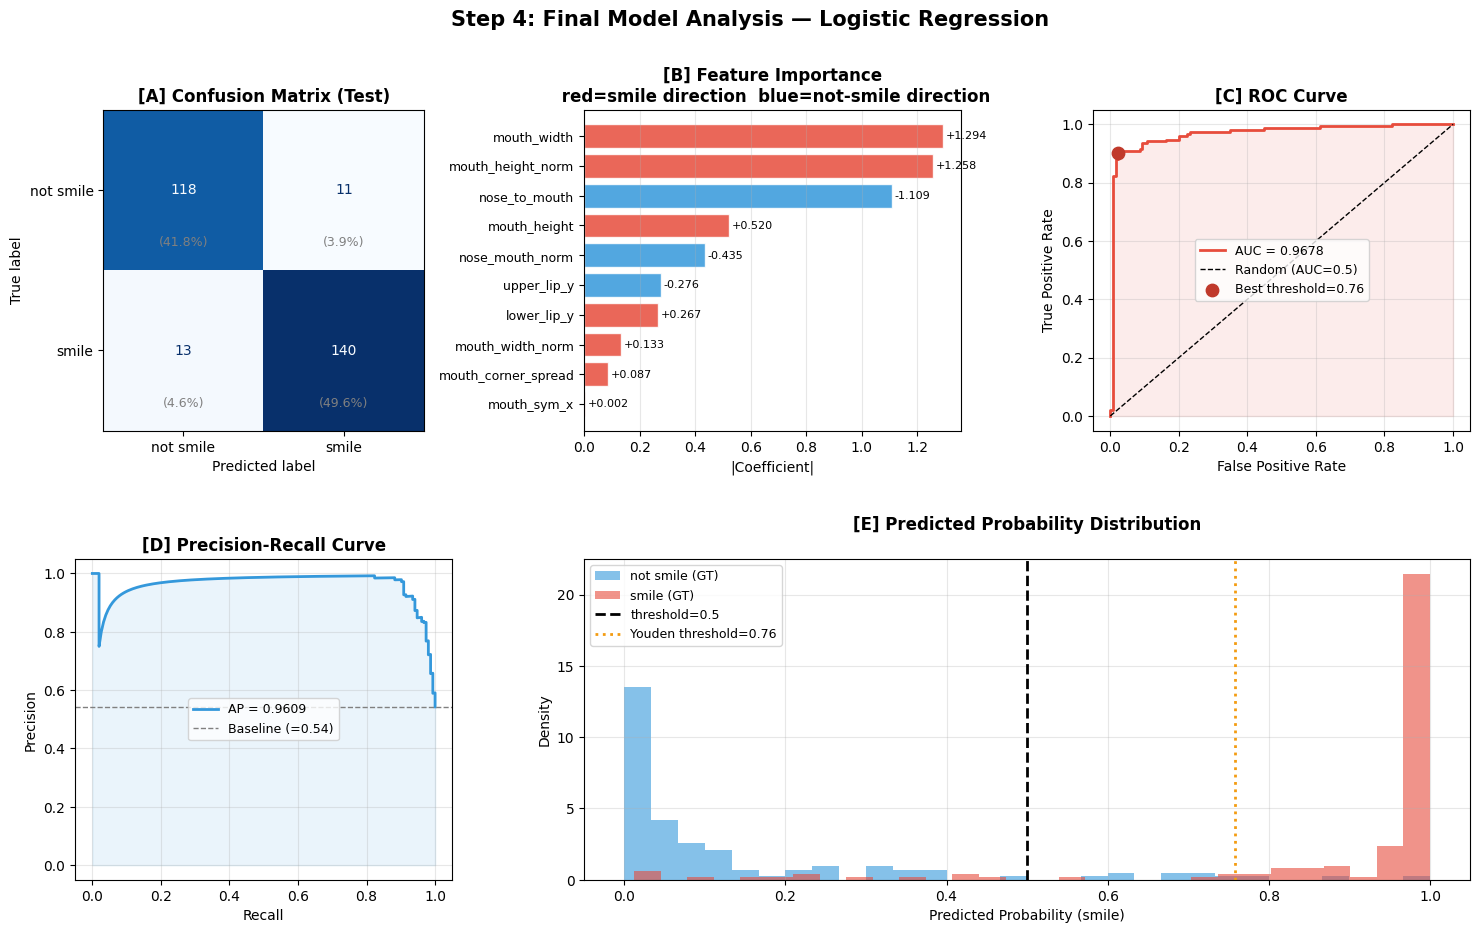

図を step4_model_analysis.png に保存しました

誤分類サンプル分析  (Test: 24件 / 282件)
  False Positive (not-smile → smile と誤判定): 11 件
  False Negative (smile → not-smile と誤判定): 13 件

  FP の予測確率 (smile): mean=0.732  min=0.586  max=1.000
  FN の予測確率 (smile): mean=0.229  min=0.012  max=0.442

  → 確率が 0.4〜0.6 に集中するほど「際どい誤分類」が多く、
    確率が端（0.1や0.9）に集中するほど特徴量の限界による誤分類


In [8]:
# 2. 最終モデルの学習
#    C パラメータの影響を確認してから最終値を決める

print("=" * 60)
print("C パラメータのチューニング（正則化強度の確認）")
print("=" * 60)
print(f"{'C':>8} | {'CV Mean':>9} | {'CV Std':>8} | {'Test Acc':>9}")
print("-" * 42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_C, best_cv = 1.0, 0.0

for C in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    m = LogisticRegression(C=C, max_iter=1000, random_state=42)
    scores = cross_val_score(m, X_tr_sc, y_train, cv=cv, scoring='accuracy')
    m.fit(X_tr_sc, y_train)
    te = m.score(X_te_sc, y_test)
    print(f"{C:>8.2f} | {scores.mean():>9.4f} | {scores.std():>8.4f} | {te:>9.4f}")
    if scores.mean() > best_cv:
        best_cv = scores.mean()
        best_C  = C

print(f"\n→ 最良 C = {best_C}  (CV Mean={best_cv:.4f})")

# 最終モデルをチューニングで求めたCで学習（CV/Test ともに安定）
model = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
model.fit(X_tr_sc, y_train)

# 3. 精度の最終確認

train_acc = model.score(X_tr_sc, y_train)
test_acc  = model.score(X_te_sc, y_test)
y_pred    = model.predict(X_te_sc)
y_proba   = model.predict_proba(X_te_sc)[:, 1]

print("\n" + "=" * 60)
print("最終モデル精度サマリー")
print("=" * 60)
print(f"  Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)")
print(f"  Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  過学習 Gap     : {train_acc - test_acc:+.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['not smile', 'smile']))

# 4. 可視化（5パネル）
#    [A] 混同行列
#    [B] 特徴量重要度（係数の絶対値）
#    [C] ROC曲線
#    [D] Precision-Recall 曲線
#    [E] 予測確率の分布（閾値の妥当性確認）

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Step 4: Final Model Analysis — Logistic Regression',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# --- [A] 混同行列 ---
ax_a = fig.add_subplot(gs[0, 0])
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['not smile', 'smile'])
disp.plot(ax=ax_a, colorbar=False, cmap='Blues')
ax_a.set_title('[A] Confusion Matrix (Test)', fontweight='bold')
# 各セルにパーセントも表示
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax_a.text(j, i + 0.35, f'({cm[i,j]/total*100:.1f}%)',
                  ha='center', fontsize=9, color='gray')

# --- [B] 特徴量重要度（係数の絶対値） ---
ax_b = fig.add_subplot(gs[0, 1])
coefs      = model.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))  # 小→大
colors_bar = ['#e74c3c' if coefs[i] > 0 else '#3498db' for i in sorted_idx]
ax_b.barh(range(len(feat_names)),
          np.abs(coefs[sorted_idx]),
          color=colors_bar, edgecolor='white', alpha=0.85)
ax_b.set_yticks(range(len(feat_names)))
ax_b.set_yticklabels([feat_names[i] for i in sorted_idx], fontsize=9)
ax_b.set_xlabel('|Coefficient|')
ax_b.set_title('[B] Feature Importance\n red=smile direction  blue=not-smile direction', fontweight='bold')
ax_b.grid(axis='x', alpha=0.3)
# 係数の値を棒の右に表示
for j, idx in enumerate(sorted_idx):
    ax_b.text(np.abs(coefs[idx]) + 0.01, j,
              f'{coefs[idx]:+.3f}', va='center', fontsize=8)

# --- [C] ROC曲線 ---
ax_c = fig.add_subplot(gs[0, 2])
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
ax_c.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
ax_c.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax_c.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
# 最適閾値（Youden's J）を点でマーク
j_scores  = tpr - fpr
opt_idx   = np.argmax(j_scores)
ax_c.scatter(fpr[opt_idx], tpr[opt_idx], s=80, color='#c0392b', zorder=5,
             label=f'Best threshold={thresholds_roc[opt_idx]:.2f}')
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('[C] ROC Curve', fontweight='bold')
ax_c.legend(fontsize=9); ax_c.grid(alpha=0.3)

# --- [D] Precision-Recall 曲線 ---
ax_d = fig.add_subplot(gs[1, 0])
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
ax_d.plot(recall, precision, color='#3498db', lw=2, label=f'AP = {ap:.4f}')
ax_d.fill_between(recall, precision, alpha=0.1, color='#3498db')
baseline = y_test.sum() / len(y_test)
ax_d.axhline(baseline, color='gray', lw=1, linestyle='--',
             label=f'Baseline (={baseline:.2f})')
ax_d.set_xlabel('Recall'); ax_d.set_ylabel('Precision')
ax_d.set_title('[D] Precision-Recall Curve', fontweight='bold')
ax_d.legend(fontsize=9); ax_d.grid(alpha=0.3)

# --- [E] 予測確率の分布（閾値0.5の妥当性確認） ---
ax_e = fig.add_subplot(gs[1, 1:])
proba_smile    = y_proba[y_test == True]
proba_nosmile  = y_proba[y_test == False]
ax_e.hist(proba_nosmile, bins=30, alpha=0.6, color='#3498db',
          label='not smile (GT)', density=True)
ax_e.hist(proba_smile,   bins=30, alpha=0.6, color='#e74c3c',
          label='smile (GT)',     density=True)
ax_e.axvline(0.5, color='black', lw=2, linestyle='--', label='threshold=0.5')
ax_e.axvline(thresholds_roc[opt_idx], color='#f39c12', lw=2, linestyle=':',
             label=f'Youden threshold={thresholds_roc[opt_idx]:.2f}')
ax_e.set_xlabel('Predicted Probability (smile)')
ax_e.set_ylabel('Density')
ax_e.set_title('[E] Predicted Probability Distribution\n',
               fontweight='bold')
ax_e.legend(fontsize=9); ax_e.grid(alpha=0.3)

plt.savefig('step4_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("図を step4_model_analysis.png に保存しました")


# 5. 誤分類サンプルの分析
#    → どんなサンプルを間違えているかを確認する

y_pred_tr = model.predict(X_tr_sc)
errors_te = np.where(y_pred != y_test)[0]
errors_tr = np.where(y_pred_tr != y_train)[0]

print("\n" + "=" * 60)
print(f"誤分類サンプル分析  (Test: {len(errors_te)}件 / {len(y_test)}件)")
print("=" * 60)

# 誤分類を FP（not-smileをsmileと判定）と FN（smileをnot-smileと判定）に分類
fp_idx = [i for i in errors_te if y_test[i] == False and y_pred[i] == True]
fn_idx = [i for i in errors_te if y_test[i] == True  and y_pred[i] == False]
print(f"  False Positive (not-smile → smile と誤判定): {len(fp_idx)} 件")
print(f"  False Negative (smile → not-smile と誤判定): {len(fn_idx)} 件")

# 誤分類サンプルの予測確率（確信度）を確認
fp_proba = y_proba[fp_idx]
fn_proba = y_proba[fn_idx]
print(f"\n  FP の予測確率 (smile): mean={fp_proba.mean():.3f}  "
      f"min={fp_proba.min():.3f}  max={fp_proba.max():.3f}")
print(f"  FN の予測確率 (smile): mean={fn_proba.mean():.3f}  "
      f"min={fn_proba.min():.3f}  max={fn_proba.max():.3f}")
print("\n  → 確率が 0.4〜0.6 に集中するほど「際どい誤分類」が多く、"
      "\n    確率が端（0.1や0.9）に集中するほど特徴量の限界による誤分類")

##ステップ５
**smile_predict関数の実装**


In [9]:
from __future__ import annotations
import numpy as np

def _build_features(facial_data: list) -> np.ndarray:
    pts = [np.array(facial_data[i + 1]) for i in range(15)]
    p = lambda n: pts[n - 1]
    face_width           = abs(p(4)[0] - p(6)[0]) + 1e-6
    mouth_width          = abs(p(13)[0] - p(12)[0])
    upper_lip_y          = float(p(14)[1])
    lower_lip_y          = float(p(15)[1])
    mouth_height         = p(15)[1] - p(14)[1]
    nose_to_mouth        = p(14)[1] - p(11)[1]
    mouth_sym_x          = (p(12)[0] + p(13)[0]) / 2.0
    mouth_corner_spread  = abs(p(12)[1] - p(13)[1])
    mouth_width_norm     = mouth_width   / face_width
    mouth_height_norm    = mouth_height  / face_width
    nose_mouth_norm      = nose_to_mouth / face_width
    return np.array([mouth_width, upper_lip_y, lower_lip_y, mouth_height,
                     nose_to_mouth, mouth_sym_x, mouth_corner_spread,
                     mouth_width_norm, mouth_height_norm, nose_mouth_norm])


def smile_predict(facial_data: list) -> bool:
    x        = _build_features(facial_data)
    x_scaled = (x - scaler.mean_) / scaler.scale_
    logit    = np.dot(model.coef_[0], x_scaled) + model.intercept_[0]
    prob     = 1.0 / (1.0 + np.exp(-logit))
    return bool(prob >= 0.76)

##ステップ６
smile_predictの精度評価

In [11]:
def calc_accuracy(split_name: str, verbose: bool = False) -> float:
    samples = data[split_name]
    correct = 0
    errors  = []

    for sample in samples:
        face_input = sample[:-1]
        gt_bool    = sample[-1]['smile']
        pred_bool  = smile_predict(face_input)
        if pred_bool == gt_bool:
            correct += 1
        else:
            errors.append({
                'id':   face_input[0],
                'pred': pred_bool,
                'gt':   gt_bool,
            })

    acc = correct / len(samples)
    print(f"  {split_name:5s}: {correct}/{len(samples)}  "
          f"Accuracy = {acc:.4f}  ({acc * 100:.2f}%)")

    if verbose and errors:
        print(f"         誤分類 {len(errors)} 件:")
        fp = [e for e in errors if e['gt'] == False]
        fn = [e for e in errors if e['gt'] == True]
        print(f"           FP (not-smile→smile): {len(fp)} 件")
        print(f"           FN (smile→not-smile): {len(fn)} 件")

    return acc


print("=" * 55)
print("最終精度確認（numpy のみ）")
print("=" * 55)
train_acc = calc_accuracy('train', verbose=True)
test_acc  = calc_accuracy('test',  verbose=True)
print("-" * 55)
print(f"  過学習 Gap: {train_acc - test_acc:+.4f}  "
      f"({'✓ 正常範囲' if abs(train_acc - test_acc) < 0.05 else '⚠ 要確認'})")


# 4. 1サンプルずつ動作確認（提出前の目視チェック）
#    → ipynb の既存評価セルと同じ出力形式

print("\n" + "=" * 55)
print("=== Test Data Predictions vs Ground Truth ===")
print("=" * 55)

test_samples = data['test']
for idx, sample in enumerate(test_samples, start=1):
    face_input = sample[:-1]
    gt_bool    = sample[-1]['smile']
    pred_bool  = smile_predict(face_input)

    gt   = 'smile'     if gt_bool   else 'not smile'
    pred = 'smile'     if pred_bool else 'not smile'
    mark = '✓' if pred_bool == gt_bool else '✗'

    print(f"[{idx:03d}] {mark} ID: {face_input[0]}  "
          f"Pred: {pred:<10}  GT: {gt}")

# 5. 関数の単体テスト
#    エッジケースで例外が出ないかを確認する

print("\n" + "=" * 55)
print("単体テスト")
print("=" * 55)

def run_test(description, facial_data, expected=None):
    try:
        result = smile_predict(facial_data)
        status = '✓ PASS'
        if expected is not None and result != expected:
            status = f'✗ FAIL (expected={expected}, got={result})'
        print(f"  {status}  {description}  → {result}")
    except Exception as e:
        print(f"  ✗ ERROR  {description}  → {e}")

# 実データからそのまま取得してテスト
sample_smile    = next(s for s in data['train'] if     s[-1]['smile'])
sample_nosmile  = next(s for s in data['train'] if not s[-1]['smile'])

run_test('実データ (smile)',     sample_smile[:-1],   expected=True)
run_test('実データ (not smile)', sample_nosmile[:-1], expected=False)


最終精度確認（numpy のみ）
  train: 592/657  Accuracy = 0.9011  (90.11%)
         誤分類 65 件:
           FP (not-smile→smile): 5 件
           FN (smile→not-smile): 60 件
  test : 262/282  Accuracy = 0.9291  (92.91%)
         誤分類 20 件:
           FP (not-smile→smile): 3 件
           FN (smile→not-smile): 17 件
-------------------------------------------------------
  過学習 Gap: -0.0280  (✓ 正常範囲)

=== Test Data Predictions vs Ground Truth ===
[001] ✓ ID: el0etgO0lV  Pred: not smile   GT: not smile
[002] ✓ ID: t0eKPqRqap  Pred: not smile   GT: not smile
[003] ✓ ID: Y5crMjuXoD  Pred: smile       GT: smile
[004] ✗ ID: 6ED4JFqQT4  Pred: smile       GT: not smile
[005] ✗ ID: uXGZOKRlG4  Pred: not smile   GT: smile
[006] ✓ ID: sCTN8vfQCl  Pred: smile       GT: smile
[007] ✓ ID: HHJILic8r7  Pred: smile       GT: smile
[008] ✓ ID: Ye6cD5YaiK  Pred: smile       GT: smile
[009] ✓ ID: vNSHMaCjlj  Pred: smile       GT: smile
[010] ✓ ID: 3M41I4E9pY  Pred: not smile   GT: not smile
[011] ✓ ID: ND2YcZbnys  Pred: smile